# **MODEL ORDER REDUCTION AND MACHINE LEARNING - Project**
**A.Y. 2025/2026**
## Francabandiera Riccardo (matricola), Morandi Simone Domenico (s336974), Pautasso Elisabetta (s337091)

Things to be checked/corrected/added are marked with !!!

## Part 0

In [1]:
# Basic imports.
import numpy as np
import argparse
import os.path
import scipy.sparse
import vtk
from pypolydim import polydim, gedim
from pypolydim.export_vtk_utilities import ExportVTKUtilities
from pypolydim.assembler_utilities import assembler_utilities

import sys
sys.path.insert(1, '../')
import other_utilities as other_ut

In [2]:
# Mesh utilities.
geometry_utilities_config = gedim.GeometryUtilitiesConfig()
geometry_utilities_config.tolerance1_d = 1.0e-6
geometry_utilities_config.tolerance2_d = 1.0e-12
geometry_utilities = gedim.GeometryUtilities(geometry_utilities_config)
mesh_utilities = gedim.MeshUtilities()
vtk_utilities = ExportVTKUtilities()

## Original problem

Solve the Navier-Stokes equation on square ${\Omega} = (0, 1)^2$

$$
\begin{cases}
-\mu_0 \nabla \cdot (\nabla \mathbf{u}) + (\nabla \mathbf{u})\mathbf{u} + \nabla p = \mathbf{f}(x;\mu_1) & \text{in } \Omega\\
(\nabla \cdot \mathbf{u}) = 0 & \text{in } \Omega\\
u = 0 & \text{in } ∂ \Omega
\end{cases}
$$

where:

$\quad u=u(\vec{\mu})$

$\quad \vec{\mu} = (\mu_0,\mu_1)$

$\quad \mu_0 \in [0.1,10]$

$\quad \mu_1 \in [1.0,3.0]$

$\quad f(x;\mu_1) = -((µ^3_1 π^2\cos(µ^2_1πx)−µ^2_1π^2)\sin(µ_1πy)\cos(µ_1πy)+(µ_1π\cos(µ_1πx)\cos(µ_1πy))$



In order to have a unique solution, we fix $p=0$ in $(0.0,0.0)$.

### Discretization

In [3]:
# Defining the square.
pde_domain = polydim.pde_tools.mesh.pde_mesh_utilities.PDE_Domain_2D()
pde_domain.vertices = np.array([[0.0, 1.0, 1.0, 0.0],
                                [0.0, 0.0, 1.0, 1.0],
                                [0.0, 0.0, 0.0, 0.0]])
pde_domain.shape_type = polydim.pde_tools.mesh.pde_mesh_utilities.PDE_Domain_2D.Domain_Shape_Types.parallelogram
pde_domain.area = 1.0

In [4]:
# Defining mesh type and quality.
mesh_type = polydim.pde_tools.mesh.pde_mesh_utilities.MeshGenerator_Types_2D.triangular
method_type = polydim.pde_tools.local_space_pcc_2_d.MethodTypes.fem_pcc
mesh_size = 0.001

In [5]:
# Generating mesh.
mesh_data = gedim.MeshMatrices()
mesh = gedim.MeshMatricesDAO(mesh_data)

polydim.pde_tools.mesh.pde_mesh_utilities.create_mesh_2_d(geometry_utilities,
                                                          mesh_utilities,
                                                          mesh_type,
                                                          pde_domain,
                                                          mesh_size,
                                                          mesh)
mesh_geometric_data = polydim.pde_tools.mesh.pde_mesh_utilities.compute_mesh_2_d_geometry_data(geometry_utilities, mesh_utilities, mesh)

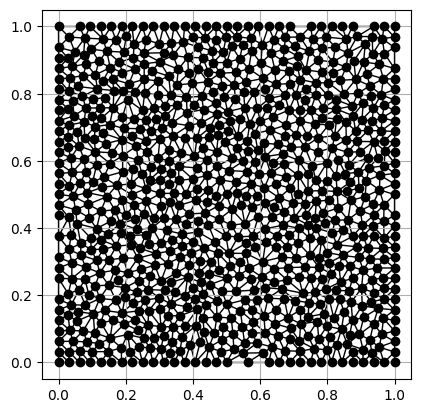

In [6]:
# Exporting and visualizing mesh.
vtk_utilities.export_mesh("./Export", mesh)
export_solution_path = "./Export/Solution" # Fixing solution path for later.
other_ut.plot_mesh(mesh)

## High fidelity approximation
We fix a value of $\mu$ and solve the N-S equations.

In [7]:
# Defining border info.
info_internal = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.none)
info_internal.marker = 0

info_dirichlet = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.strong)
info_dirichlet.marker = 1

info_neumann_none = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.none)
info_neumann_none.marker = 0

# p=0 on all borders.
pressure_boundary_info = {
    0: info_internal,
    1: info_dirichlet,
    2: info_neumann_none,
    3: info_neumann_none,
    4: info_neumann_none,
    5: info_neumann_none,
    6: info_neumann_none,
    7: info_neumann_none,
    8: info_neumann_none
}

# u=v=0 on all borders.
speed_boundary_info = {
    0: info_internal,
    1: info_dirichlet,
    2: info_dirichlet,
    3: info_dirichlet,
    4: info_dirichlet,
    5: info_dirichlet,
    6: info_dirichlet,
    7: info_dirichlet,
    8: info_dirichlet
}

In [8]:
# Creating Taylor-Hood finite element.
mesh_connectivity_data = polydim.pde_tools.mesh.MeshMatricesDAO_mesh_connectivity_data(mesh)

pressure_reference_element_data = polydim.pde_tools.local_space_pcc_2_d.create_reference_element(method_type, 
                                                                                              1)
speed_reference_element_data = polydim.pde_tools.local_space_pcc_2_d.create_reference_element(method_type, 
                                                                                             2)

dof_manager = polydim.pde_tools.do_fs.DOFsManager()

pressure_mesh_dofs_info = polydim.pde_tools.local_space_pcc_2_d.set_mesh_do_fs_info(pressure_reference_element_data, 
                                                                                    mesh, 
                                                                                    pressure_boundary_info)
pressure_dofs_data = dof_manager.create_do_fs_2_d(pressure_mesh_dofs_info, 
                                                  mesh_connectivity_data)

speed_mesh_dofs_info = polydim.pde_tools.local_space_pcc_2_d.set_mesh_do_fs_info(speed_reference_element_data, 
                                                                                 mesh, 
                                                                                 speed_boundary_info)
speed_dofs_data = dof_manager.create_do_fs_2_d(speed_mesh_dofs_info, 
                                               mesh_connectivity_data)

In [9]:
# Defining dofs.
pressure_n_dofs = pressure_dofs_data.number_do_fs
pressure_n_strongs = pressure_dofs_data.number_strongs
speed_n_dofs = speed_dofs_data.number_do_fs
speed_n_strongs = speed_dofs_data.number_strongs
tot_dofs = 2 * speed_n_dofs + pressure_n_dofs
tot_strongs = 2 * speed_n_strongs + pressure_n_strongs
print("P dofs\t", "P stgs\t", "U dofs\t", "U stgs\t", "T dofs\t", "T stgs")
print(pressure_n_dofs,"\t", pressure_n_strongs,"\t", speed_n_dofs,"\t", speed_n_strongs,"\t", tot_dofs,"\t", tot_strongs)

P dofs	 P stgs	 U dofs	 U stgs	 T dofs	 T stgs
829 	 1 	 2966 	 234 	 6761 	 469


In [10]:
# Defining a fixed mu value.
mu_fixed = [5.0,3.0]

In [11]:
# Defining source term function and its discrete comoponents.
def f_x_function(x, y, z, mu):
    term1 = -(mu[1]**3 * np.pi**2 * np.cos(mu[1]**2 * np.pi * x) \
              - mu[1]**2 * np.pi**2) \
             * np.sin(mu[1] * np.pi * y) * np.cos(mu[1] * np.pi * y)
    term2 = mu[1] * np.pi * np.cos(mu[1] * np.pi * x) * np.cos(mu[1] * np.pi * y)
    return term1 + term2

def f_y_function(x, y, z):
    return np.zeros_like(x) # f(x,mu) doesn't depend on y.

f_x = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_reference_element_data,
                                                                       lambda x,y,z: f_x_function(x,y,z,mu_fixed))
f_y = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_reference_element_data,
                                                                       f_y_function)

f_S = np.concatenate([f_x, f_y, np.zeros(pressure_n_dofs)])

In [12]:
# Defining pressure function and its discrete components.
def pressure_strong_function(marker, x, y, z):
    return np.zeros_like(x)

p_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       pressure_mesh_dofs_info,
                                                                       pressure_dofs_data,
                                                                       pressure_reference_element_data,
                                                                       pressure_strong_function)

In [13]:
# Defining speed functions and their discrete components.
def speed_x_strong_function(marker, x, y, z):
    return np.zeros_like(x)

def speed_y_strong_function(marker, x, y, z):
    return np.zeros_like(x)

u_x_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_mesh_dofs_info,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_x_strong_function)
u_y_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_mesh_dofs_info,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_y_strong_function)

In [14]:
# Defining matrix.
def mu_0_term(x, y, z, mu):  
    return mu[0]
def b_x_term(x, y, z):  
    return np.array([\
        1.0,\
        0.0,\
        0.0])
def b_y_term(x, y, z):  
    return np.array([\
        0.0,\
        1.0,\
        0.0])

A_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_diffusion_operator(geometry_utilities,
                                                                                       mesh,
                                                                                       mesh_geometric_data,
                                                                                       speed_dofs_data,
                                                                                       speed_dofs_data,
                                                                                       speed_reference_element_data,
                                                                                       speed_reference_element_data,
                                                                                        lambda x,y,z: mu_0_term(x,y,z,mu_fixed))


J_A_x = other_ut.make_np_sparse(A_operator.operator_dofs, [tot_dofs, tot_dofs], [0, 0])
J_A_y = other_ut.make_np_sparse(A_operator.operator_dofs, [tot_dofs, tot_dofs], [speed_n_dofs, speed_n_dofs])

B_x_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       pressure_dofs_data,
                                                                       speed_reference_element_data,
                                                                       pressure_reference_element_data,
                                                                       b_x_term)
B_y_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       pressure_dofs_data,
                                                                       speed_reference_element_data,
                                                                       pressure_reference_element_data,
                                                                       b_y_term)

J_B_x = other_ut.make_np_sparse(B_x_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, 0])
J_B_y = other_ut.make_np_sparse(B_y_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, speed_n_dofs])
J_BT_x = other_ut.make_np_sparse(B_x_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, 0], True)
J_BT_y = other_ut.make_np_sparse(B_y_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, speed_n_dofs], True)


J_S = J_A_x + J_A_y - J_B_x - J_B_y - J_BT_x - J_BT_y

In [15]:
# Defining vectors of the numerical solution.
def speed_x_initial_condition(x, y, z):  
    return 0.0
def speed_y_initial_condition(x, y, z):  
    return 0.0
def pressure_initial_condition(x, y, z):  
    return 0.0

u_x_numeric = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(geometry_utilities,
                                                                                mesh,
                                                                                mesh_geometric_data,
                                                                                speed_dofs_data,
                                                                                speed_reference_element_data,
                                                                                speed_x_initial_condition).function_dofs
u_y_numeric = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(geometry_utilities,
                                                                                mesh,
                                                                                mesh_geometric_data,
                                                                                speed_dofs_data,
                                                                                speed_reference_element_data,
                                                                                speed_y_initial_condition).function_dofs
p_numeric = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(geometry_utilities,
                                                                                mesh,
                                                                                mesh_geometric_data,
                                                                                pressure_dofs_data,
                                                                                pressure_reference_element_data,
                                                                                pressure_initial_condition).function_dofs

u_k = np.concatenate([u_x_numeric, u_y_numeric, p_numeric])
du_x_strong = np.zeros(speed_n_strongs)
du_y_strong = np.zeros(speed_n_strongs)
dp_strong = np.zeros(pressure_n_strongs)

## Newton's Method

In [16]:
# Newtons' Method.
# Initializing
residual_norm = 1.0
solution_norm = 1.0
newton_tol = 1.0e-6
max_iterations = 10
num_iteration = 1
# While loop.
while num_iteration < max_iterations and residual_norm > newton_tol * solution_norm: 
    # (nabla u)u discrete term.
    c_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_ns_operators(geometry_utilities,
                                                                                     mesh,
                                                                                     mesh_geometric_data,
                                                                                     speed_dofs_data,
                                                                                     speed_reference_element_data,
                                                                                     u_x_numeric,
                                                                                     u_y_numeric,
                                                                                     u_x_strong,
                                                                                     u_y_strong)
    
    J_C = other_ut.make_np_sparse(c_operator.convective_operator.operator_dofs, [tot_dofs, tot_dofs], [0, 0])
    f_C = np.concatenate([c_operator.convective_rhs, np.zeros(pressure_n_dofs)])

    J_f = f_S - f_C - J_S @ u_k
    du = scipy.sparse.linalg.spsolve(J_S + J_C, J_f)
    
    u_k = u_k + du

    du_x = du[0:speed_n_dofs]
    du_y = du[speed_n_dofs:2 * speed_n_dofs]
    dp = du[2 * speed_n_dofs:]

    u_x_numeric = u_k[0:speed_n_dofs]
    u_y_numeric = u_k[speed_n_dofs:2 * speed_n_dofs]
    p_numeric = u_k[2 * speed_n_dofs:]

    du_x_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                 mesh,
                                                                                 mesh_geometric_data,
                                                                                 speed_dofs_data,
                                                                                 speed_reference_element_data,
                                                                                 du_x,
                                                                                 du_x_strong)
    du_y_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                 mesh,
                                                                                 mesh_geometric_data,
                                                                                 speed_dofs_data,
                                                                                 speed_reference_element_data,
                                                                                 du_y,
                                                                                 du_y_strong)
    dp_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                 mesh,
                                                                                 mesh_geometric_data,
                                                                                 pressure_dofs_data,
                                                                                 pressure_reference_element_data,
                                                                                 dp,
                                                                                 dp_strong)
    """ !!! Use this for the evaluation with an exact solution
    u_x_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                mesh,
                                                                                mesh_geometric_data,
                                                                                speed_dofs_data,
                                                                                speed_reference_element_data,
                                                                                u_x_numeric,
                                                                                u_x_strong,
                                                                                speed_x_exact)
    u_y_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                mesh,
                                                                                mesh_geometric_data,
                                                                                speed_dofs_data,
                                                                                speed_reference_element_data,
                                                                                u_y_numeric,
                                                                                u_y_strong,
                                                                                speed_y_exact)
    p_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                mesh,
                                                                                mesh_geometric_data,
                                                                                pressure_dofs_data,
                                                                                pressure_reference_element_data,
                                                                                p_numeric,
                                                                                p_strong,
                                                                                pressure_exact)
    solution_norm = np.sqrt(u_x_error_L2.numeric_norm_l2 * u_x_error_L2.numeric_norm_l2 + 
                           u_y_error_L2.numeric_norm_l2 * u_y_error_L2.numeric_norm_l2 +
                           p_error_L2.numeric_norm_l2 * p_error_L2.numeric_norm_l2);
    """
    residual_norm = np.sqrt(du_x_error_L2.numeric_norm_l2 * du_x_error_L2.numeric_norm_l2 + 
                           du_y_error_L2.numeric_norm_l2 * du_y_error_L2.numeric_norm_l2 +
                           dp_error_L2.numeric_norm_l2 * dp_error_L2.numeric_norm_l2);
    """
    print("dofs", "u_x_errorL2", "u_y_errorL2", "p_errorL2", "residual", "iteration", "max_iteration")
    print(tot_dofs, '{:.2e}'.format(u_x_error_L2.error_l2 / u_x_error_L2.numeric_norm_l2), '{:.2e}'.format(u_y_error_L2.error_l2 / u_y_error_L2.numeric_norm_l2), '{:.2e}'.format(p_error_L2.error_l2 / p_error_L2.numeric_norm_l2), '{:.16e}'.format(residual_norm / solution_norm), '{:d}'.format(num_iteration), '{:d}'.format(max_iterations))
    """
    print("dofs", "residual", "iteration", "max_iteration")
    print(tot_dofs, '{:.16e}'.format(residual_norm / solution_norm), '{:d}'.format(num_iteration), '{:d}'.format(max_iterations))
    num_iteration = num_iteration + 1

dofs residual iteration max_iteration
6761 6.1443111278492797e+00 1 10
dofs residual iteration max_iteration
6761 2.6904277610200925e-04 2 10
dofs residual iteration max_iteration
6761 1.5858690509775123e-12 3 10


In [17]:
u_x_on_cell0Ds = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(mesh,
                                                                       speed_dofs_data,
                                                                                         u_x_numeric,
                                                                                         u_x_strong,
                                                                       )
u_y_on_cell0Ds = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(mesh,
                                                                       speed_dofs_data,
                                                                                         u_y_numeric,
                                                                                         u_y_strong,
                                                                       )
p_on_cell0Ds = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(mesh,
                                                                       pressure_dofs_data,
                                                                                         p_numeric,
                                                                                         p_strong,
                                                                       )

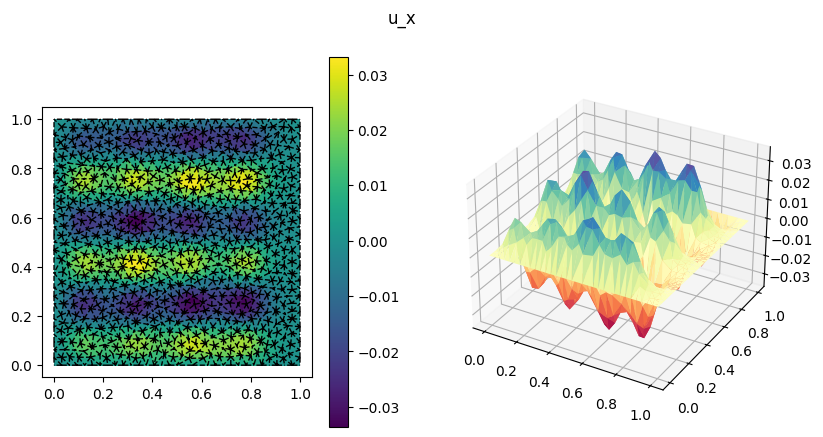

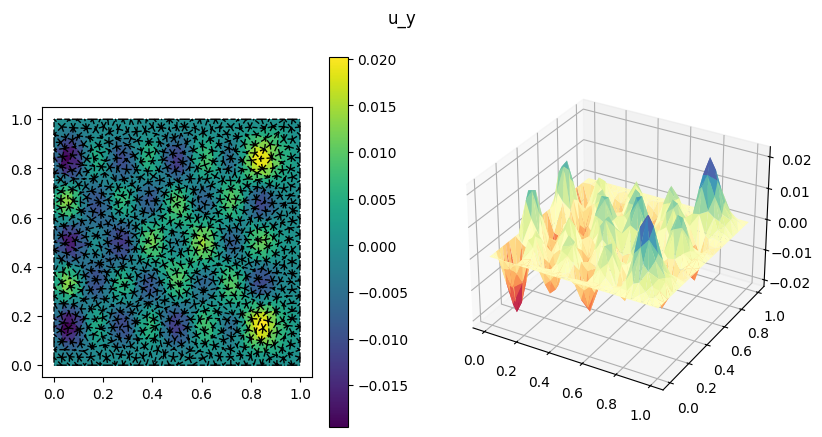

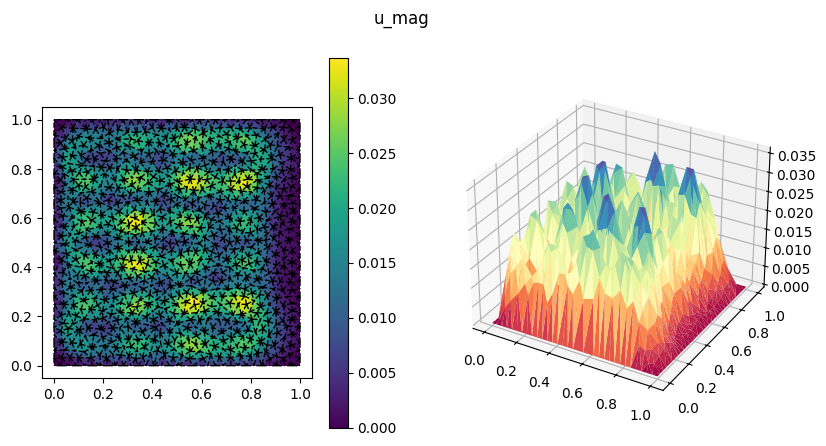

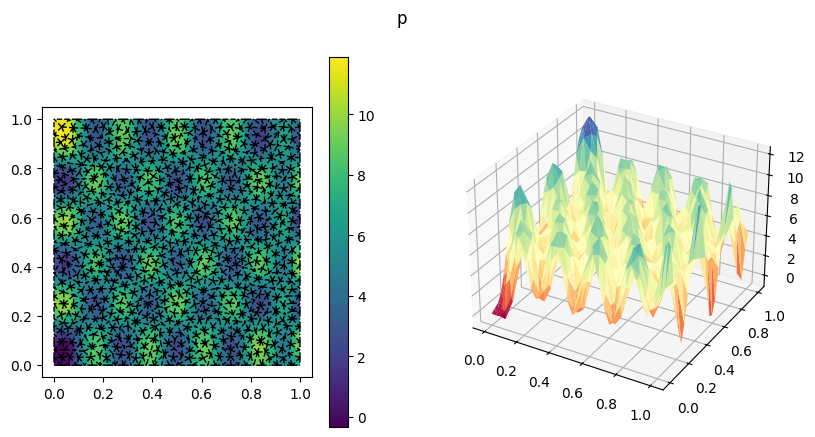

In [18]:
# Exporting and plotting the numerical solution.
other_ut.plot_solution(mesh, u_x_on_cell0Ds.numeric_solution, "u_x") 
other_ut.plot_solution(mesh, u_y_on_cell0Ds.numeric_solution, "u_y")
other_ut.plot_solution(mesh, np.sqrt(u_x_on_cell0Ds.numeric_solution * u_x_on_cell0Ds.numeric_solution + u_y_on_cell0Ds.numeric_solution * u_y_on_cell0Ds.numeric_solution), "u_mag")
other_ut.plot_solution(mesh, p_on_cell0Ds.numeric_solution, "p") 

We were able to solve the N-S equations numerically for a fixed value of $\vec{\mu}$. 

Now we can proceed with the POD. 

# Offline Phase for POD

In [19]:
# Defining training set.
snapshot_num = 100
mu0_range = [0.1, 10.0]
mu1_range = [1.0, 3.0]
P = np.array([mu0_range, mu1_range])

np.random.seed(0)
training_set = np.random.uniform(low=P[:, 0], high=P[:, 1], size=(snapshot_num, P.shape[0]))

In [20]:
# Defining utilities matrices.
X_1 = other_ut.make_np_sparse(A_operator.operator_dofs, [2 * speed_n_dofs, 2 * speed_n_dofs], [0, 0])
X_2 = other_ut.make_np_sparse(A_operator.operator_dofs, [2 * speed_n_dofs, 2 * speed_n_dofs], [speed_n_dofs, speed_n_dofs])
B_1 = other_ut.make_np_sparse(B_x_operator.operator_dofs, [pressure_n_dofs, 2 * speed_n_dofs], [0, 0])
B_2 = other_ut.make_np_sparse(B_y_operator.operator_dofs, [pressure_n_dofs, 2 * speed_n_dofs], [0, speed_n_dofs])

In [22]:
def solve_ns(mu):
    print(mu)
    f_x = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_reference_element_data,
                                                                       lambda x,y,z: f_x_function(x,y,z,mu))
    f_y = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                           mesh,
                                                                           mesh_geometric_data,
                                                                           speed_dofs_data,
                                                                           speed_reference_element_data,
                                                                           speed_reference_element_data,
                                                                           f_y_function)
    
    f_S = np.concatenate([f_x, f_y, np.zeros(pressure_n_dofs)])

    p_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       pressure_mesh_dofs_info,
                                                                       pressure_dofs_data,
                                                                       pressure_reference_element_data,
                                                                       pressure_strong_function)
    u_x_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_mesh_dofs_info,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_x_strong_function)
    u_y_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                           mesh,
                                                                           mesh_geometric_data,
                                                                           speed_mesh_dofs_info,
                                                                           speed_dofs_data,
                                                                           speed_reference_element_data,
                                                                           speed_y_strong_function)
    A_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_diffusion_operator(geometry_utilities,
                                                                                       mesh,
                                                                                       mesh_geometric_data,
                                                                                       speed_dofs_data,
                                                                                       speed_dofs_data,
                                                                                       speed_reference_element_data,
                                                                                       speed_reference_element_data,
                                                                                       lambda x,y,z: mu_0_term(x,y,z,mu))


    J_A_x = other_ut.make_np_sparse(A_operator.operator_dofs, [tot_dofs, tot_dofs], [0, 0])
    J_A_y = other_ut.make_np_sparse(A_operator.operator_dofs, [tot_dofs, tot_dofs], [speed_n_dofs, speed_n_dofs])
    
    B_x_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(geometry_utilities,
                                                                           mesh,
                                                                           mesh_geometric_data,
                                                                           speed_dofs_data,
                                                                           pressure_dofs_data,
                                                                           speed_reference_element_data,
                                                                           pressure_reference_element_data,
                                                                           b_x_term)
    B_y_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(geometry_utilities,
                                                                           mesh,
                                                                           mesh_geometric_data,
                                                                           speed_dofs_data,
                                                                           pressure_dofs_data,
                                                                           speed_reference_element_data,
                                                                           pressure_reference_element_data,
                                                                           b_y_term)
    
    J_B_x = other_ut.make_np_sparse(B_x_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, 0])
    J_B_y = other_ut.make_np_sparse(B_y_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, speed_n_dofs])
    J_BT_x = other_ut.make_np_sparse(B_x_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, 0], True)
    J_BT_y = other_ut.make_np_sparse(B_y_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, speed_n_dofs], True)
    
    
    J_S = J_A_x + J_A_y - J_B_x - J_B_y - J_BT_x - J_BT_y
    u_x_numeric = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(geometry_utilities,
                                                                                    mesh,
                                                                                    mesh_geometric_data,
                                                                                    speed_dofs_data,
                                                                                    speed_reference_element_data,
                                                                                    speed_x_initial_condition).function_dofs
    u_y_numeric = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(geometry_utilities,
                                                                                    mesh,
                                                                                    mesh_geometric_data,
                                                                                    speed_dofs_data,
                                                                                    speed_reference_element_data,
                                                                                    speed_y_initial_condition).function_dofs
    p_numeric = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(geometry_utilities,
                                                                                    mesh,
                                                                                    mesh_geometric_data,
                                                                                    pressure_dofs_data,
                                                                                    pressure_reference_element_data,
                                                                                    pressure_initial_condition).function_dofs
    
    u_k = np.concatenate([u_x_numeric, u_y_numeric, p_numeric])
    du_x_strong = np.zeros(speed_n_strongs)
    du_y_strong = np.zeros(speed_n_strongs)
    dp_strong = np.zeros(pressure_n_strongs)

    # Newtons' Method.
    residual_norm = 1.0
    solution_norm = 1.0
    newton_tol = 1.0e-6
    max_iterations = 10
    num_iteration = 1
    while num_iteration < max_iterations and residual_norm > newton_tol * solution_norm: 
        c_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_ns_operators(geometry_utilities,
                                                                                         mesh,
                                                                                         mesh_geometric_data,
                                                                                         speed_dofs_data,
                                                                                         speed_reference_element_data,
                                                                                         u_x_numeric,
                                                                                         u_y_numeric,
                                                                                         u_x_strong,
                                                                                         u_y_strong)
        
        J_C = other_ut.make_np_sparse(c_operator.convective_operator.operator_dofs, [tot_dofs, tot_dofs], [0, 0])
        f_C = np.concatenate([c_operator.convective_rhs, np.zeros(pressure_n_dofs)])
    
        J_f = f_S - f_C - J_S @ u_k
        du = scipy.sparse.linalg.spsolve(J_S + J_C, J_f)
        
        u_k = u_k + du
    
        du_x = du[0:speed_n_dofs]
        du_y = du[speed_n_dofs:2 * speed_n_dofs]
        dp = du[2 * speed_n_dofs:]
    
        u_x_numeric = u_k[0:speed_n_dofs]
        u_y_numeric = u_k[speed_n_dofs:2 * speed_n_dofs]
        p_numeric = u_k[2 * speed_n_dofs:]

        du_x_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                         mesh,
                                                                                         mesh_geometric_data,
                                                                                         speed_dofs_data,
                                                                                         speed_reference_element_data,
                                                                                         du_x,
                                                                                         du_x_strong)
        du_y_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                     mesh,
                                                                                     mesh_geometric_data,
                                                                                     speed_dofs_data,
                                                                                     speed_reference_element_data,
                                                                                     du_y,
                                                                                     du_y_strong)
        dp_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                     mesh,
                                                                                     mesh_geometric_data,
                                                                                     pressure_dofs_data,
                                                                                     pressure_reference_element_data,
                                                                                     dp,
                                                                                     dp_strong)
        
        residual_norm = np.sqrt(du_x_error_L2.numeric_norm_l2 * du_x_error_L2.numeric_norm_l2 + 
                           du_y_error_L2.numeric_norm_l2 * du_y_error_L2.numeric_norm_l2 +
                           dp_error_L2.numeric_norm_l2 * dp_error_L2.numeric_norm_l2);
        """
        print("dofs", "u_x_errorL2", "u_y_errorL2", "p_errorL2", "residual", "iteration", "max_iteration")
        print(tot_dofs, '{:.2e}'.format(u_x_error_L2.error_l2 / u_x_error_L2.numeric_norm_l2), '{:.2e}'.format(u_y_error_L2.error_l2 / u_y_error_L2.numeric_norm_l2), '{:.2e}'.format(p_error_L2.error_l2 / p_error_L2.numeric_norm_l2), '{:.16e}'.format(residual_norm / solution_norm), '{:d}'.format(num_iteration), '{:d}'.format(max_iterations))
        """
        print("dofs", "residual", "iteration", "max_iteration")
        print(tot_dofs, '{:.16e}'.format(residual_norm / solution_norm), '{:d}'.format(num_iteration), '{:d}'.format(max_iterations))
        num_iteration = num_iteration + 1
    return u_k

In [24]:
# Assembling the snaphots matrix.
snapshot_matrix_u = []
snapshot_matrix_s = [] # Supremizer snapshot.
snapshot_matrix_p = []

# Initializing
tol = 1. - 1e-7
N_max = 20

print("Performing training...")
it = 0
for mu in training_set:
    if it % 10 == 0:
      print("\tIterations", 2 * it, " /", training_set.size)
    it = it + 1
    
    snapshot_solution = solve_ns(mu)
    snapshot_u = snapshot_solution[0:2 * speed_n_dofs]
    snapshot_matrix_u.append(np.copy(snapshot_u))
    
    snapshot_p = snapshot_solution[2 * speed_n_dofs:]
    snapshot_matrix_p.append(np.copy(snapshot_p))
    
    snapshot_s = scipy.sparse.linalg.spsolve(X_1 + X_2, np.transpose(B_1 + B_2) @ snapshot_p)
    snapshot_matrix_s.append(np.copy(snapshot_s)) 

snapshot_matrix_u = np.array(snapshot_matrix_u)
snapshot_matrix_s = np.array(snapshot_matrix_s)
snapshot_matrix_p = np.array(snapshot_matrix_p)  

print("Training performed")

Performing training...
	Iterations 0  / 200
[5.53325369 2.43037873]
dofs residual iteration max_iteration
6761 4.6628787554637858e+00 1 10
dofs residual iteration max_iteration
6761 2.1832083757753769e-04 2 10
dofs residual iteration max_iteration
6761 6.6352576297990650e-13 3 10
[6.06735742 2.08976637]
dofs residual iteration max_iteration
6761 3.6901129776097505e+00 1 10
dofs residual iteration max_iteration
6761 2.0314840425618178e-04 2 10
dofs residual iteration max_iteration
6761 3.4736052146880973e-13 3 10
[4.29418251 2.29178823]
dofs residual iteration max_iteration
6761 4.2561687380555098e+00 1 10
dofs residual iteration max_iteration
6761 3.6714457057309509e-04 2 10
dofs residual iteration max_iteration
6761 1.3414002427240586e-12 3 10
[4.43211339 2.783546  ]
dofs residual iteration max_iteration
6761 5.6574572081634553e+00 1 10
dofs residual iteration max_iteration
6761 3.3177506068827442e-04 2 10
dofs residual iteration max_iteration
6761 1.4028161665465466e-12 3 10
[9.64026

In [25]:
# Defining inner product of X matrices for eigenvalues analysis.
inner_product_u = X_1 + X_2

In [26]:
# Function that returns the dimension and the eigenvalue of the Covariance matrix.
def eig_analysis(C, N_max=None, tol=1e-9):
  L_e, VM_e = np.linalg.eig(C)
  eigenvalues = []
  eigenvectors = []

  for i in range(len(L_e)):
    eig_real = L_e[i].real
    eig_complex = L_e[i].imag
    assert np.isclose(eig_complex, 0.)
    eigenvalues.append(eig_real)
    eigenvectors.append(VM_e[i].real)


  total_energy = sum(eigenvalues)
  retained_energy_vector = np.cumsum(eigenvalues)
  relative_retained_energy = retained_energy_vector/total_energy


  if all(flag==False for flag in relative_retained_energy>= tol) and N_max != None:
    N = N_max
  else:
    N = np.argmax(relative_retained_energy >= tol) + 1
  
  return N, eigenvectors

In [27]:
# Assembling covariance matrix from snapshot matrices.
C_u = snapshot_matrix_u @ inner_product_u @ np.transpose(snapshot_matrix_u)
C_s = snapshot_matrix_s @ inner_product_u @ np.transpose(snapshot_matrix_s)
C_p = snapshot_matrix_p @ np.transpose(snapshot_matrix_p)

N_u, eigs_u = eig_analysis(C_u, N_max=N_max, tol=tol)
N_s, eigs_s = eig_analysis(C_s, N_max=N_max, tol=tol)
N_p, eigs_p = eig_analysis(C_p, N_max=N_max, tol=tol)

print(N_u, N_s, N_p)

19 24 20


In [28]:
# Function that creates basis functions from snapshots and eigenvectors of the covariance matrix.
def create_basis_functions_matrix(N, snapshot_matrix, eigenvectors, inner_product=None):
  
  basis_functions = []
  
  for n in range(N):
    eigenvector =  eigenvectors[n]
    basis = np.transpose(snapshot_matrix)@eigenvector
    if inner_product!= None:
      norm = np.sqrt(np.transpose(basis) @ inner_product @ basis)
    else:
      norm = np.sqrt(np.transpose(basis) @ basis)
    basis /= norm
    basis_functions.append(np.copy(basis))

  basis_function_matrix = np.transpose(np.array(basis_functions))
  
  return basis_function_matrix

In [29]:
# Creating basis functions.
basis_functions_u = create_basis_functions_matrix(N_u, snapshot_matrix_u, eigs_u, inner_product=inner_product_u)
basis_functions_s = create_basis_functions_matrix(N_s, snapshot_matrix_s, eigs_s, inner_product=inner_product_u)
basis_functions_p = create_basis_functions_matrix(N_p, snapshot_matrix_p, eigs_p)

In [31]:
# Solving the N-S equations
print(basis_functions_u.shape)
print(basis_functions_p.shape)
print(basis_functions_u.shape[0] + basis_functions_p.shape[0])
print(basis_functions_p.shape)

global_basis_function_matrix = np.zeros((basis_functions_u.shape[0] + basis_functions_p.shape[0],N_u + N_s + N_p))
global_basis_function_matrix[0:basis_functions_u.shape[0], 0:N_u] = basis_functions_u
global_basis_function_matrix[0:basis_functions_u.shape[0], N_u : N_u + N_s] = basis_functions_s
global_basis_function_matrix[basis_functions_u.shape[0]:, N_u + N_s:] = basis_functions_p
print(global_basis_function_matrix.shape)

global_basis_function_matrix_no_sup = np.zeros((basis_functions_u.shape[0] + basis_functions_p.shape[0],N_u + N_p))
global_basis_function_matrix_no_sup[0:basis_functions_u.shape[0], 0:N_u] = basis_functions_u
global_basis_function_matrix_no_sup[basis_functions_u.shape[0]:, N_u:] = basis_functions_p

(5932, 19)
(829, 20)
6761
(829, 20)
(6761, 63)


In [32]:
# Function that assembles reduced matrix.
def assemble_reduced_matrix(basis, fom_matrix):
  return np.transpose(basis) @ (fom_matrix) @ basis

# Function that asse,bles reduced vector.
def assemble_reduced_vector(basis, fom_vector):
  return np.transpose(basis) @ (fom_vector)

In [33]:
# Assembling reduced system.
reduced_stiff_Stokes = assemble_reduced_matrix(global_basis_function_matrix, (J_A_x + J_A_y)) 
reduced_divergence_operator_1 = assemble_reduced_matrix(global_basis_function_matrix, (J_BT_x)) 
reduced_divergence_operator_2 = assemble_reduced_matrix(global_basis_function_matrix, (J_BT_y))

## Online Phase for POD

In [40]:
# Fixing a new value of mu and solving the system.
mu_new = [2.0,1.5]

# Updating f_x and f_y since they depend on mu
f_x = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_reference_element_data,
                                                                       lambda x,y,z: f_x_function(x,y,z,mu_new))
f_y = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                   mesh,
                                                                   mesh_geometric_data,
                                                                   speed_dofs_data,
                                                                   speed_reference_element_data,
                                                                   speed_reference_element_data,
                                                                   f_y_function)

J_f = np.concatenate([f_x, f_y, np.zeros(pressure_n_dofs)])

# Updating with mu_0.
reduced_lhs = mu[0]*reduced_stiff_Stokes - reduced_divergence_operator_1 - reduced_divergence_operator_2 - np.transpose(reduced_divergence_operator_1) - np.transpose(reduced_divergence_operator_2)
reduced_rhs = assemble_reduced_vector(global_basis_function_matrix, J_f)

In [41]:
# Solving with the reduced system.
reduced_solution = np.linalg.solve(reduced_lhs, reduced_rhs)

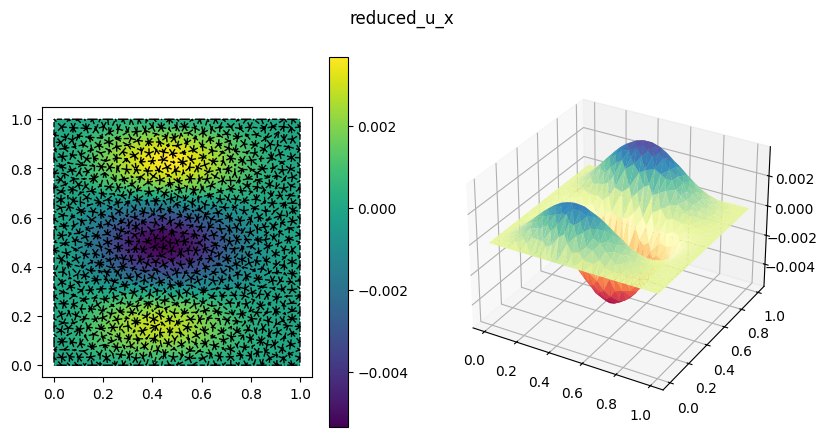

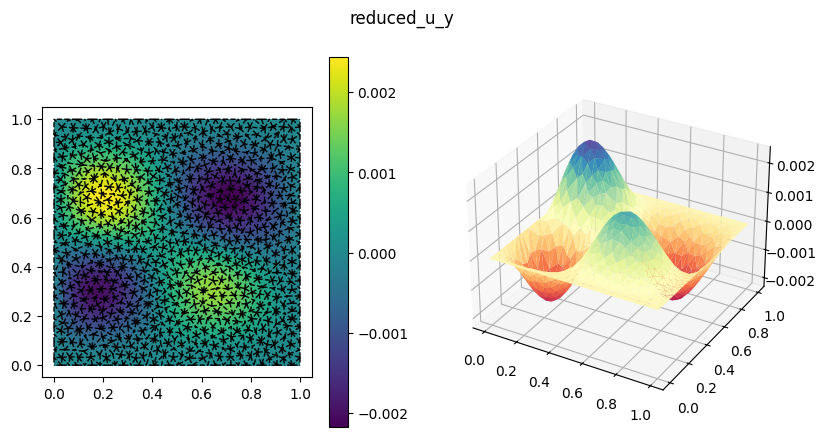

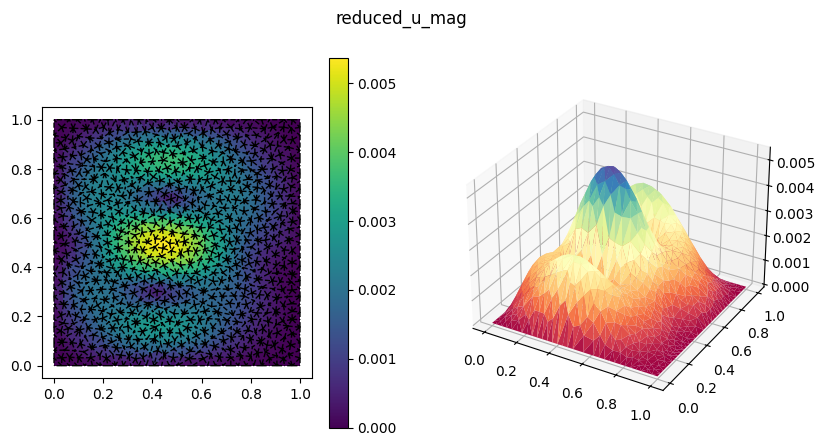

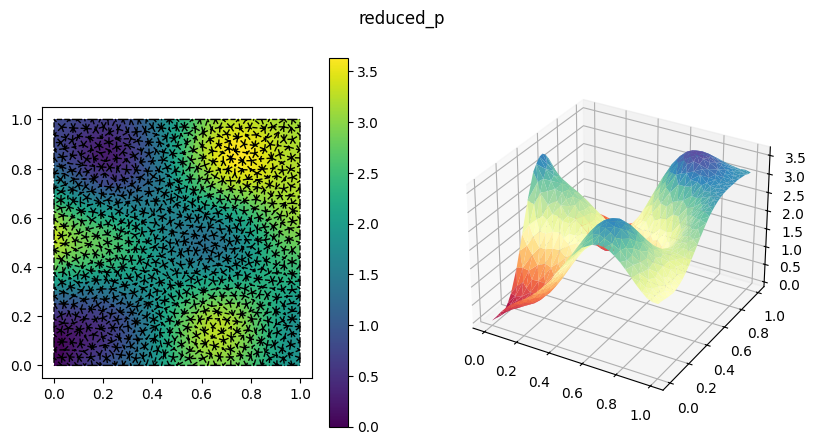

In [42]:
# Plotting the solution.
reduced_u_dof = N_u + N_s
reduced_p_dof = N_p
reduced_solution_FE_basis = global_basis_function_matrix @ reduced_solution
reduced_u_x = reduced_solution_FE_basis[0:speed_n_dofs]
reduced_u_y = reduced_solution_FE_basis[speed_n_dofs:2 * speed_n_dofs]
reduced_p = reduced_solution_FE_basis[2 * speed_n_dofs:]

reduced_u_x_on_cell0Ds = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(mesh,
                                                                       speed_dofs_data,
                                                                                         reduced_u_x,
                                                                                         u_x_strong,
                                                                       )
reduced_u_y_on_cell0Ds = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(mesh,
                                                                       speed_dofs_data,
                                                                                         reduced_u_y,
                                                                                         u_y_strong,
                                                                       )
reduced_p_on_cell0Ds = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(mesh,
                                                                       pressure_dofs_data,
                                                                                         reduced_p,
                                                                                         p_strong,
                                                                       )

vtk_utilities.export_solution_2(export_solution_path + '/reduced_u_x',
                                mesh, 
                                reduced_u_x_on_cell0Ds.numeric_solution)
vtk_utilities.export_solution_2(export_solution_path + '/reduced_u_y',
                                mesh, 
                                reduced_u_y_on_cell0Ds.numeric_solution)
vtk_utilities.export_solution_2(export_solution_path + '/reduced_p',
                                mesh, 
                                reduced_p_on_cell0Ds.numeric_solution)
other_ut.plot_solution(mesh, reduced_u_x_on_cell0Ds.numeric_solution, "reduced_u_x") 
other_ut.plot_solution(mesh, reduced_u_y_on_cell0Ds.numeric_solution, "reduced_u_y")
other_ut.plot_solution(mesh, np.sqrt(reduced_u_x_on_cell0Ds.numeric_solution * reduced_u_x_on_cell0Ds.numeric_solution + reduced_u_y_on_cell0Ds.numeric_solution * reduced_u_y_on_cell0Ds.numeric_solution), "reduced_u_mag")
other_ut.plot_solution(mesh, reduced_p_on_cell0Ds.numeric_solution, "reduced_p") 

In [43]:
# Function that computes the error between the FOM solution and the POD solution.
def compute_error(fom_solution, rom_solution_FE_basis, inner_product=None, type_err="relative"):
    
    error_function_u = fom_solution - rom_solution_FE_basis
    
    if inner_product == None:
        inner_product_matrix = np.identity(fom_solution.shape[0])
    else:
      inner_product_matrix = inner_product
    
    error_norm_squared_component = np.transpose(error_function_u) @ inner_product_matrix @ error_function_u
    absolute_error = np.sqrt(abs(error_norm_squared_component))
    
    if type_err == "absolute":
      return absolute_error
    else:
      full_solution_norm_squared_component = np.transpose(fom_solution) @  inner_product_matrix @ fom_solution
      relative_error = absolute_error/np.sqrt(abs(full_solution_norm_squared_component))
    
      return relative_error 

In [44]:
# Computing errors and seepd-up
import time

# Initializing.
abs_err_u = []
rel_err_u = []

abs_err_p = []
rel_err_p = []

# Defining testing set.
np.random.seed(4) 
testing_set = np.random.uniform(low=P[:, 0], high=P[:, 1], size=(100, P.shape[0]))
speed_up = []

print("Computing error and speedup analysis...")

it = 0
for mu in testing_set:

  if it % 10 == 0:
      print("\tIterations", 2 * it, " /", testing_set.size)
  it = it + 1
  
  #### the problem is not affine: I have to assemble in this stage!! ###
  start_time_assemble = time.time()
  f_x = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_reference_element_data,
                                                                       lambda x,y,z: f_x_function(x,y,z,mu))
  f_y = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                   mesh,
                                                                   mesh_geometric_data,
                                                                   speed_dofs_data,
                                                                   speed_reference_element_data,
                                                                   speed_reference_element_data,
                                                                   f_y_function)

  J_f = np.concatenate([f_x, f_y, np.zeros(pressure_n_dofs)])
  lhs = mu[0]*(J_A_x + J_A_y) - J_B_x - J_B_y - J_BT_x - J_BT_y
  rhs = J_f
  time_assemble = time.time() - start_time_assemble
  
  start_fom = time.time()
  full_solution = snapshot_solution = scipy.sparse.linalg.spsolve(lhs, rhs)
  time_fom = time.time() - start_fom

  full_solution_u = full_solution[0:2*speed_n_dofs]
  full_solution_p = full_solution[2*speed_n_dofs:]

  reduced_lhs = mu[0]*reduced_stiff_Stokes - reduced_divergence_operator_1 - reduced_divergence_operator_2 - np.transpose(reduced_divergence_operator_1) - np.transpose(reduced_divergence_operator_2)
  reduced_rhs = assemble_reduced_vector(global_basis_function_matrix, J_f)

  start_rom = time.time()
  reduced_solution = np.linalg.solve(reduced_lhs, reduced_rhs)
  time_rom = time.time() - start_rom
  
  speed_up.append(time_fom/(time_rom+time_assemble))
  
  reduced_solution_FE_basis = global_basis_function_matrix @ reduced_solution
  reduced_u_FE = reduced_solution_FE_basis[0:2*speed_n_dofs]
  reduced_p_FE = reduced_solution_FE_basis[2*speed_n_dofs:]

  ### computing error
  
  abs_err_u_mu = compute_error(full_solution_u, reduced_u_FE, inner_product=inner_product_u, type_err="absolute")
  rel_err_u_mu = compute_error(full_solution_u, reduced_u_FE, inner_product=inner_product_u)
  abs_err_u.append(abs_err_u_mu)
  rel_err_u.append(rel_err_u_mu)

  abs_err_p_mu = compute_error(full_solution_p, reduced_p_FE, type_err="absolute")
  rel_err_p_mu = compute_error(full_solution_p, reduced_p_FE)
  abs_err_p.append(abs_err_p_mu)
  rel_err_p.append(rel_err_p_mu)

print("Error and speedup analysis performed")

Computing error and speedup analysis...
	Iterations 0  / 200
	Iterations 20  / 200
	Iterations 40  / 200
	Iterations 60  / 200
	Iterations 80  / 200
	Iterations 100  / 200
	Iterations 120  / 200
	Iterations 140  / 200
	Iterations 160  / 200
	Iterations 180  / 200
Error and speedup analysis performed


In [39]:
print("avarege relative error for velocity = ", np.mean(rel_err_u) )
print("avarege absolute error for velocity = ", np.mean(abs_err_u) )

print("avarege relative error for pressure = ", np.mean(rel_err_p) )
print("avarege absolute error for pressure = ", np.mean(abs_err_p) )


print("avarege speed_up = ", np.mean(speed_up) )

avarege relative error for velocity =  0.0059582561512572
avarege absolute error for velocity =  0.0013319659780685093
avarege relative error for pressure =  0.0014083911681044383
avarege absolute error for pressure =  0.14458542772032226
avarege speed_up =  1.8529838000468215


...

In order to validate this (at the end), we could try computing the error given this exact solution:

$\vec{u} = (u,y), p$

$u = +\frac{1}{2}  \sin(2  \pi  x)^2 \sin(2 \pi y) \cos(2 \pi y)$

$v = -\frac{1}{2}  \sin(2 \pi  y)^2  \sin(2  \pi  x)  \cos(2 \pi  x)$

$p = \pi^2 \sin(2  \pi  x)  \cos(2  \pi  y)$

Which gives the following exact operators: (follow LAB 13 step by step)

In [ ]:
"""
def speed_x_exact_laplacian(x, y, z):
    return mu[0]*(+2.0 * np.pi * np.pi * np.sin(4.0 * np.pi * y) * (2.0 * np.cos(4.0 * np.pi * x) - 1.0))
def speed_y_exact_laplacian(x, y, z):
    return mu[0]*(-2.0 * np.pi * np.pi * np.sin(4.0 * np.pi * x) * (2.0 * np.cos(4.0 * np.pi * y) - 1.0))
def pressure_exact_gradient(x, y, z):
    return np.array([\
        +2.0 * np.pi * np.pi * np.pi * np.cos(2.0 * np.pi * x) * np.cos(2.0 * np.pi * y),\
        -2.0 * np.pi * np.pi * np.pi * np.sin(2.0 * np.pi * x) * np.sin(2.0 * np.pi * y),\
        0.0])

def f_x_function(x, y, z):
    p_grad = pressure_exact_gradient(x, y, z)
    u_x_lap = speed_x_exact_laplacian(x, y, z)

    c_x = (np.pi * np.cos(2.0 * np.pi * x) * np.sin(2.0 * np.pi * x) * np.sin(2.0 * np.pi * x) * np.sin(2.0 * np.pi * x) * np.sin(2.0 * np.pi * y) * np.sin(2.0 * np.pi * y)) * 0.5

    return -mu[0] * u_x_lap + c_x + p_grad[0]
def f_y_function(x, y, z):
    p_grad = pressure_exact_gradient(x, y, z)
    u_y_lap = speed_y_exact_laplacian(x, y, z)

    c_y = (np.pi * np.cos(2.0 * np.pi * y) * np.sin(2.0 * np.pi * x) * np.sin(2.0 * np.pi * x) * np.sin(2.0 * np.pi * y) * np.sin(2.0 * np.pi * y) * np.sin(2.0 * np.pi * y)) * 0.5

    return -mu[0] * u_y_lap + c_y + p_grad[1];
"""